# 📊 미니 프로젝트- 택시요금 데이터 다루기

📌 프로젝트 수행 방법
이번 프로젝트에서 사용할 데이터 이름은 trip.csv입니다.
다양한 변수들을 활용하여 “택시 요금”을 예측한다는 가정하에 데이터를 정제해보세요.

지금까지 배운 내용을 최대한 활용하여 문제가 되는 부분을 찾아 정리하고, 최대한 변수들을 머신러닝 알고리즘에 활용 가능하도록 만들어봅시다.

In [9]:
import os

data_dir = os.path.join(os.getcwd(), "data", "trip.csv")
data = pd.read_csv("trip.csv")
data.head()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


## Step 1

Q. 결측치 판단 및 처리
[힌트] 결측치의 유무와 비율을 살펴보고 적절한 방법으로 처리합니다.

결측치 확인 및 비율 계산

In [11]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv("trip.csv")

# 전체 행 수
total_rows = len(df)

# 결측치 개수와 비율
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean()
})

print(missing_summary)




                       missing_count  missing_ratio
passenger_name                     0       0.000000
tpep_pickup_datetime               0       0.000000
tpep_dropoff_datetime              0       0.000000
payment_method                     0       0.000000
passenger_count                    0       0.000000
trip_distance                      0       0.000000
fare_amount                        3       0.000132
tip_amount                         0       0.000000
tolls_amount                       0       0.000000


결측치 처리 전략 수집

In [16]:
# 결측치 비율 30% 이상 컬럼 제거
drop_cols = missing_summary[missing_summary["missing_ratio"] >= 0.3].index
df = df.drop(columns=drop_cols)

print("제거된 컬럼:", list(drop_cols))


제거된 컬럼: []


In [19]:
# 수치형 컬럼 선택
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# 중앙값으로 결측치 대체
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [20]:
# 범주형 컬럼 선택
cat_cols = df.select_dtypes(include=["object"]).columns

# 최빈값으로 결측치 대체
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
# 처리후 저장
df.to_csv("trip_clean.csv", index=False)
print(df.isnull().sum())


passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              0
tip_amount               0
tolls_amount             0
dtype: int64


결측치의 유무와 비율을 확인한 후, 결측치 비율이 30% 이상인 변수는 제거하였다.
수치형 변수는 중앙값으로, 범주형 변수는 최빈값으로 결측치를 대체하여 데이터 손실을 최소화하였다.

Q. 이상치 판단 및 처리
[힌트] 숫자형 변수 각각에 대해, 데이터의 index와 변수 값 사이의 scatter plot을 그려보고 이상치가 관찰될 경우 제거합니다.

숫자형 변수 선택

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("trip_clean.csv")  # 결측치 처리된 파일 사용 권장

# 숫자형 변수 선택
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(num_cols)


Index(['passenger_count', 'trip_distance', 'fare_amount', 'tip_amount',
       'tolls_amount'],
      dtype='object')


index vs 값 scatter plot 그리기 (이상치 판단)

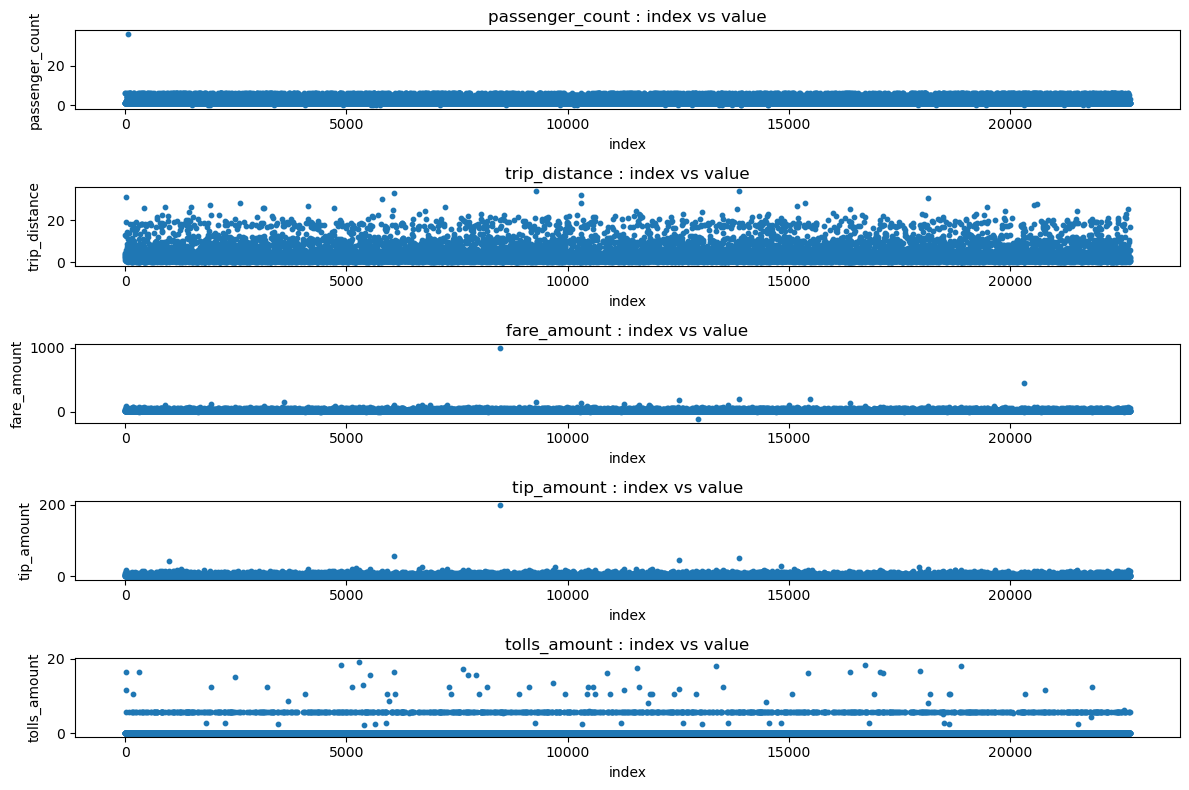

In [25]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols), 1, i + 1)
    plt.scatter(df.index, df[col], s=10)
    plt.title(f"{col} : index vs value")
    plt.xlabel("index")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


이상치 제거 기준 설정 (IQR 방식)

In [26]:
# 이상치 제거 함수 정의
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return data[(data[column] >= lower) & (data[column] <= upper)]


숫자형 변수별 이상치 제거

In [27]:
df_out = df.copy()

for col in num_cols:
    before = len(df_out)
    df_out = remove_outliers_iqr(df_out, col)
    after = len(df_out)
    print(f"{col}: {before - after}개 이상치 제거")


passenger_count: 2291개 이상치 제거
trip_distance: 2265개 이상치 제거
fare_amount: 422개 이상치 제거
tip_amount: 87개 이상치 제거
tolls_amount: 31개 이상치 제거


이상치 제거 후 scatter plot 재확인

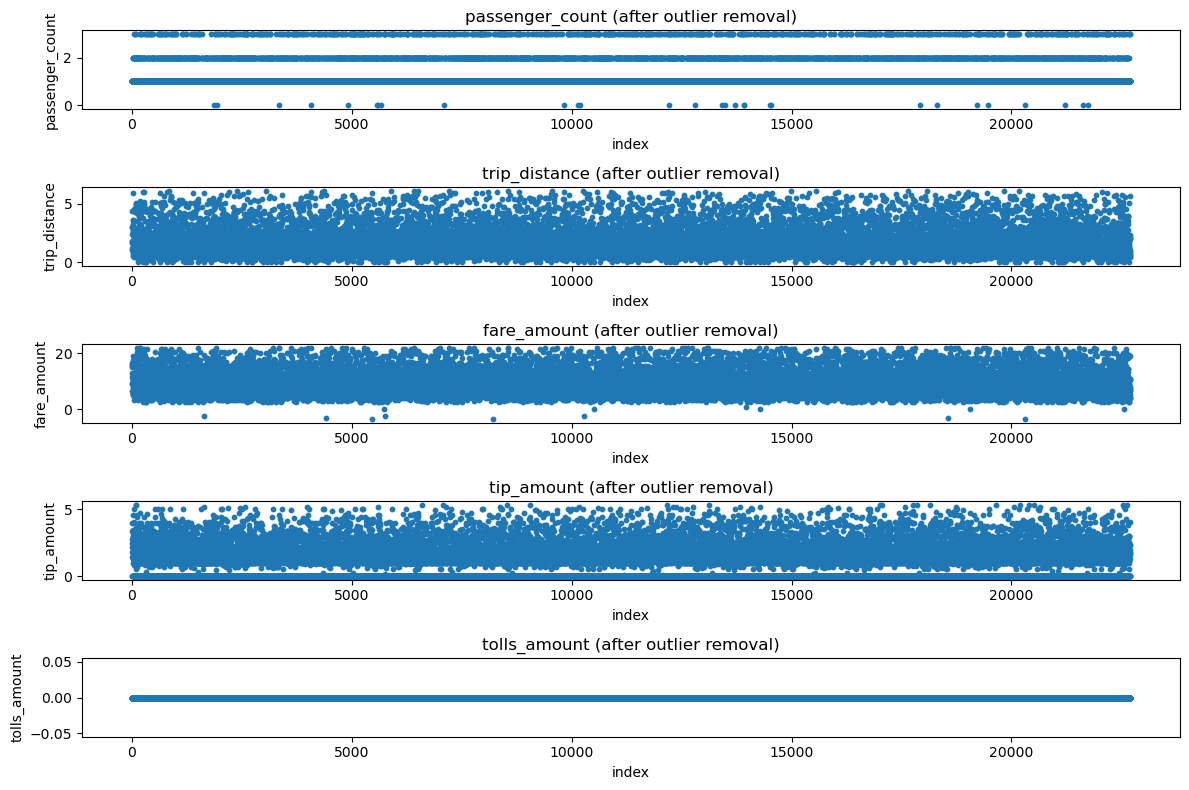

In [28]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols), 1, i + 1)
    plt.scatter(df_out.index, df_out[col], s=10)
    plt.title(f"{col} (after outlier removal)")
    plt.xlabel("index")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


In [30]:
# 처리후 저장
df_out.to_csv("trip_outlier_removed.csv", index=False)


숫자형 변수 각각에 대해 데이터의 index와 변수 값 간의 scatter plot을 시각화하여 이상치를 판단하였다.
일부 변수에서 다른 값들과 비교해 극단적으로 벗어난 값이 관찰되어 이상치로 판단하였으며,
IQR(사분위 범위) 기준을 적용하여 해당 이상치를 제거하였다.

# step 2


Q. 택시 탑승 및 하차 시간을 활용

탑승·하차 시간 → 주행 시간 생성

In [ ]:
import pandas as pd

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# 비정상 값 제거
df = df[df["trip_duration_min"] > 0]

df[[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_min"
]].head()



,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_min
0,2017-04-11 14:53:28,2017-04-11 15:19:58,26.500000
1,2017-12-15 07:26:56,2017-12-15 07:34:08,7.200000
2,2017-04-15 23:32:20,2017-04-15 23:49:03,16.716667
3,2017-08-15 17:41:06,2017-08-15 18:03:05,21.983333
4,2017-02-04 16:17:07,2017-02-04 16:29:14,12.116667


주행 시간 · 주행 거리 · 요금 상관관계 분석

In [42]:
analysis_cols = [
    "trip_duration_min",
    "trip_distance",
    "fare_amount"
]

corr_matrix = df[analysis_cols].corr()
print(corr_matrix)


                   trip_duration_min  trip_distance  fare_amount
trip_duration_min           1.000000       0.374974     0.871875
trip_distance               0.374974       1.000000     0.780507
fare_amount                 0.871875       0.780507     1.000000


상관관계 시각화 (scatter plot)

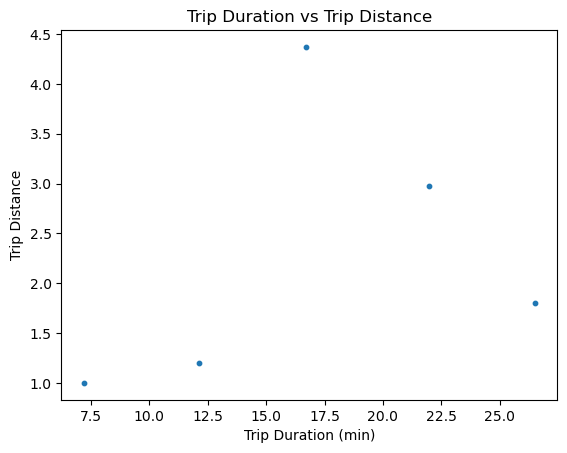

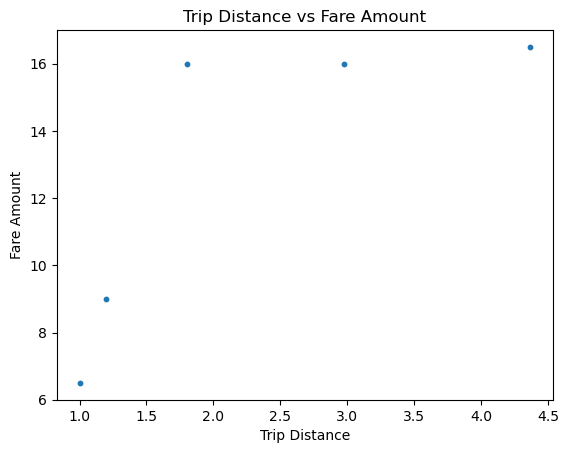

In [43]:
import matplotlib.pyplot as plt

# 주행 시간 vs 주행 거리
plt.scatter(df["trip_duration_min"], df["trip_distance"], s=10)
plt.xlabel("Trip Duration (min)")
plt.ylabel("Trip Distance")
plt.title("Trip Duration vs Trip Distance")
plt.show()

# 주행 거리 vs 요금
plt.scatter(df["trip_distance"], df["fare_amount"], s=10)
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Trip Distance vs Fare Amount")
plt.show()


## 결과
주행 시간과 주행 거리 사이에는 양의 상관관계가 나타나며,
이는 주행 시간이 길어질수록 이동 거리가 증가하는 경향이 있음을 의미한다.

주행 거리와 요금 사이에는 강한 양의 상관관계가 관찰되어,
요금이 주행 거리에 크게 의존함을 확인할 수 있다.

주행 시간과 요금 또한 양의 상관관계를 보여,
교통 상황이나 이동 시간 역시 요금에 영향을 줄 수 있음을 알 수 있다.

Q. Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보시오

In [49]:
# 1. 결제 관련 컬럼 자동으로 찾기
payment_cols = [col for col in df.columns if "payment" in col.lower()]

payment_cols


['payment_method']

찾은 컬럼을 기준으로 처리

In [50]:
pay_col = payment_cols[0]

# 숫자 코드인 경우 → 문자로 변환 (NYC 택시 기준)
payment_map = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
}

df[pay_col] = df[pay_col].map(payment_map).fillna(df[pay_col])

# Credit / Debit → Card 통합
df.loc[
    df[pay_col].astype(str).str.contains("Credit|Debit", case=False, na=False),
    pay_col
] = "Card"


결과 확인

In [51]:
df[pay_col].value_counts()


payment_method
Card    4
Cash    1
Name: count, dtype: int64